# 14. Фильтр Калмана

**Статус:** завершено

Фильтр Калмана оценивает скрытое состояние линейной гауссовской системы по шумным наблюдениям. Это рекурсивная формула условного математического ожидания: прогнозируем состояние, видим измерение, корректируем прогноз.

## Модель

Скалярная state-space модель:

$$x_t = a x_{t-1}+w_t,\quad w_t\sim N(0,Q),$$

$$y_t = h x_t+v_t,\quad v_t\sim N(0,R).$$

Фильтр хранит оценку $\hat x_{t|t}$ и дисперсию ошибки $P_{t|t}$. Коэффициент Калмана

$$K_t=\frac{P_{t|t-1}h}{h^2P_{t|t-1}+R}
$$

показывает, насколько доверять новому наблюдению. Если шум наблюдения большой, $K_t$ меньше; если прогноз неопределённый, $K_t$ больше.

In [1]:
import os
import sys
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.kalman_filter import (
    apply_scalar_kalman_filter,
    calculate_root_mean_squared_error,
    plot_kalman_filter_results,
    plot_kalman_gain_and_uncertainty,
    simulate_local_level_state_space_model,
)

## 1. Скрытое состояние и шумные наблюдения

,Показатель,Значение
0,RMSE наблюдений,0.7412
1,RMSE фильтра,0.3755
2,последний Kalman gain,0.2381
3,последняя posterior variance,0.1524


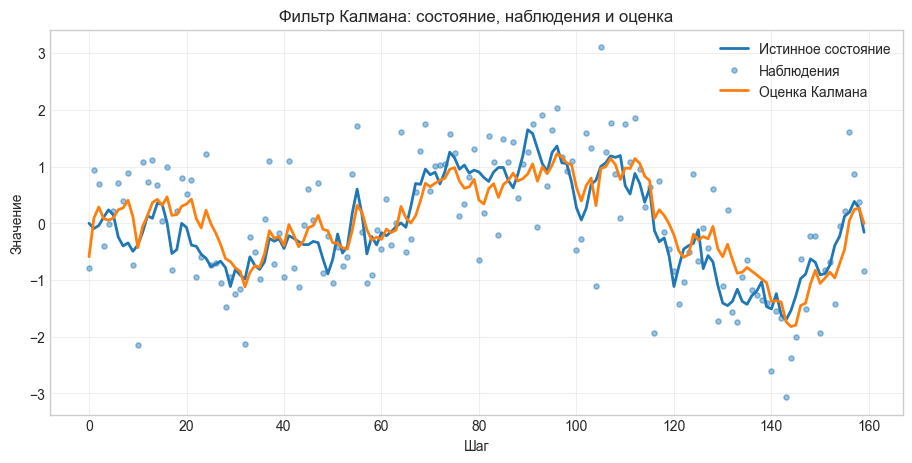

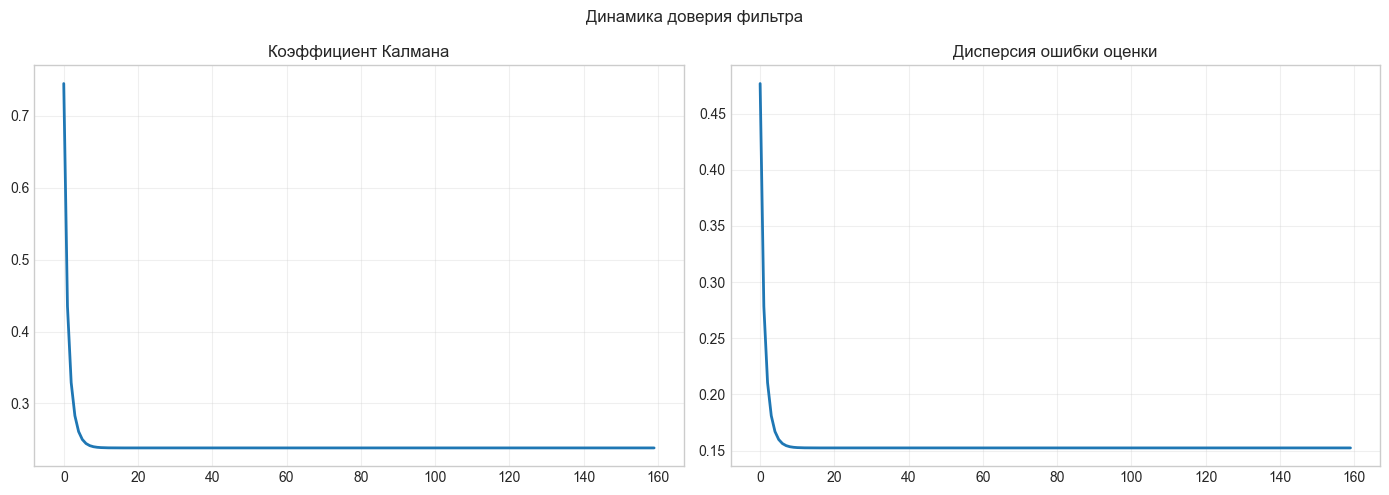

In [2]:
states, observations = simulate_local_level_state_space_model(160, 0.0, 0.95, 0.25, 0.8, random_seed=123)
estimates, variances, gains = apply_scalar_kalman_filter(observations, 0.95, 1.0, 0.25**2, 0.8**2, 0.0, 2.0)
plot_kalman_filter_results(states, observations, estimates, "Фильтр Калмана: состояние, наблюдения и оценка");
plot_kalman_gain_and_uncertainty(gains, variances, "Динамика доверия фильтра");

pd.DataFrame({
    "Показатель": ["RMSE наблюдений", "RMSE фильтра", "последний Kalman gain", "последняя posterior variance"],
    "Значение": [calculate_root_mean_squared_error(states, observations), calculate_root_mean_squared_error(states, estimates), gains[-1], variances[-1]]
})

Фильтр сильно сглаживает шум: RMSE сырых наблюдений `0.7412`, RMSE оценки `0.3755`. Последний Kalman gain около `0.2381`, то есть фильтр берёт только часть нового измерения и остальное оставляет прогнозу.

Дисперсия ошибки быстро падает от начальной неопределённости и стабилизируется около `0.1524`. Это steady-state поведение: при постоянных параметрах фильтр выходит на устойчивый баланс между шумом процесса и шумом наблюдения.

## 2. Как шумы меняют доверие фильтра

In [3]:
rows=[]
for obs_std in [0.3, 0.8, 1.5]:
    s, y = simulate_local_level_state_space_model(160,0,0.95,0.25,obs_std,random_seed=44)
    e, p, k = apply_scalar_kalman_filter(y,0.95,1,0.25**2,obs_std**2,0,2)
    rows.append({"observation_noise_std": obs_std, "RMSE observations": calculate_root_mean_squared_error(s,y), "RMSE filter": calculate_root_mean_squared_error(s,e), "steady gain": k[-1]})
pd.DataFrame(rows)

,observation_noise_std,RMSE observations,RMSE filter,steady gain
0,0.3,0.3206,0.2539,0.5421
1,0.8,0.8549,0.4556,0.2381
2,1.5,1.6030,0.6015,0.1193


Когда шум наблюдений растёт, фильтр меньше доверяет измерениям: steady gain снижается. При малом шуме наблюдение почти напрямую информирует состояние; при большом шуме фильтр становится осторожным и больше полагается на модель динамики.

## Выводы

1. Фильтр Калмана — рекурсивное условное ожидание в линейной гауссовской модели.
2. Он объединяет прогноз модели и новое наблюдение через Kalman gain.
3. Чем шумнее наблюдения, тем меньше вес нового измерения.
4. Фильтр не просто сглаживает: он также оценивает собственную неопределённость.
5. В финансах та же идея применяется для скрытого тренда, латентной доходности, спредов и noisy signals.